In [10]:
import pandas as pd

In [24]:
df=pd.read_csv('/content/sales_data.csv')

In [12]:
pd.set_option('display.max_columns',None)

In [25]:
df

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1010,2023-04-15,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie
996,1067,2023-09-07,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob
997,1018,2023-04-27,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David
998,1100,2023-12-20,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [15]:
df.isnull().sum()

,0
Product_ID,0
Sale_Date,0
Sales_Rep,0
Region,0
Sales_Amount,0
Quantity_Sold,0
Product_Category,0
Unit_Cost,0
Unit_Price,0
Customer_Type,0


In [16]:
df[df.duplicated()]

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep


In [26]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null   object        
 13  Region_and_Sales_Re

In [28]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [29]:
for i in df.select_dtypes(include=["object"]).columns:
  df[i]= label.fit_transform(df[i])

In [30]:
df

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,1,1,5053.97,18,3,152.75,267.22,1,0.09,1,0,6
1,1093,2023-04-21,1,3,4384.02,17,3,3816.39,4209.44,1,0.11,1,1,16
2,1015,2023-09-21,3,2,4631.23,30,2,261.56,371.40,1,0.20,0,1,13
3,1072,2023-08-24,1,2,2167.94,39,0,4330.03,4467.75,0,0.02,2,1,11
4,1061,2023-03-24,2,0,3750.20,13,1,637.37,692.71,0,0.08,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1010,2023-04-15,2,1,4733.88,4,2,4943.03,5442.15,1,0.29,1,0,7
996,1067,2023-09-07,1,1,4716.36,37,0,1754.32,1856.40,0,0.21,0,1,6
997,1018,2023-04-27,3,2,7629.70,17,0,355.72,438.27,1,0.06,0,0,13
998,1100,2023-12-20,3,3,1629.47,39,1,3685.03,3743.39,0,0.01,0,0,18


In [33]:
import numpy as np
from scipy.stats import zscore
df['z_sales'] = zscore(df['Sales_Amount'])
outliers = df[np.abs(df['z_sales']) > 3]
# outlier detection

In [34]:
df

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,z_sales
0,1052,2023-02-03,1,1,5053.97,18,3,152.75,267.22,1,0.09,1,0,6,0.012197
1,1093,2023-04-21,1,3,4384.02,17,3,3816.39,4209.44,1,0.11,1,1,16,-0.223256
2,1015,2023-09-21,3,2,4631.23,30,2,261.56,371.40,1,0.20,0,1,13,-0.136374
3,1072,2023-08-24,1,2,2167.94,39,0,4330.03,4467.75,0,0.02,2,1,11,-1.002094
4,1061,2023-03-24,2,0,3750.20,13,1,637.37,692.71,0,0.08,2,0,2,-0.446011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1010,2023-04-15,2,1,4733.88,4,2,4943.03,5442.15,1,0.29,1,0,7,-0.100298
996,1067,2023-09-07,1,1,4716.36,37,0,1754.32,1856.40,0,0.21,0,1,6,-0.106456
997,1018,2023-04-27,3,2,7629.70,17,0,355.72,438.27,1,0.06,0,0,13,0.917434
998,1100,2023-12-20,3,3,1629.47,39,1,3685.03,3743.39,0,0.01,0,0,18,-1.191339


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

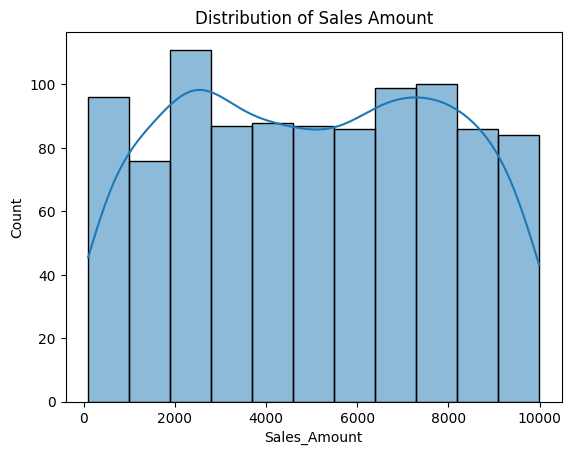

Shapiro-Wilk p-value: 5.783212268766994e-17


In [36]:
from scipy.stats import shapiro

sns.histplot(df['Sales_Amount'], kde=True)
plt.title('Distribution of Sales Amount')
plt.show()

stat, p = shapiro(df['Sales_Amount'])
print(f"Shapiro-Wilk p-value: {p}")

# What is the distribution of Sales_Amount? Is it normally distributed?
# The histogram with KDE gives a visual sense, while Shapiro-Wilk tests for normality. If p < 0.05, data is not normally distributed.

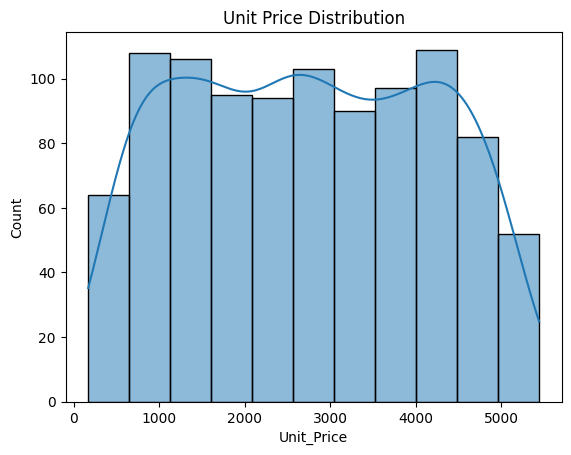

Skewness: 0.023337784117791114


In [37]:
sns.histplot(df['Unit_Price'], kde=True)
plt.title('Unit Price Distribution')
plt.show()

print("Skewness:", df['Unit_Price'].skew())
# Does Unit_Price follow a normal or skewed distribution?
# The skewness metric helps identify the direction of skew:Skew ≈ 0 → symmetric, Skew > 0 → right-skewed, Skew < 0 → left-skewed

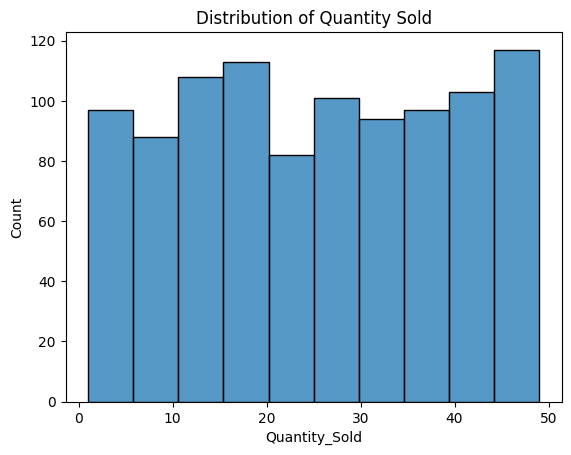

In [39]:
sns.histplot(df['Quantity_Sold'], bins=10, kde=False)
plt.title('Distribution of Quantity Sold')
plt.show()

# Are Quantity_Sold values uniformly distributed?
# A flat histogram would suggest a uniform distribution. Real sales data usually clusters (e.g., most values between 10–40).

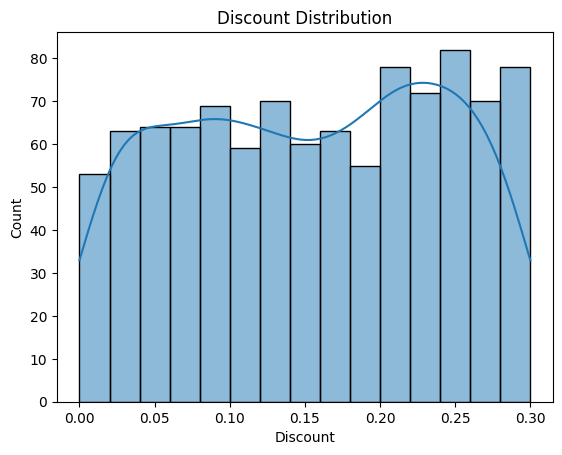

In [40]:
sns.histplot(df['Discount'], kde=True, bins=15)
plt.title('Discount Distribution')
plt.show()

# Does Discount show a bimodal or unimodal distribution?
# Check if the KDE line shows one peak (unimodal) or two/more peaks (bimodal). This may indicate tiered discount policies.

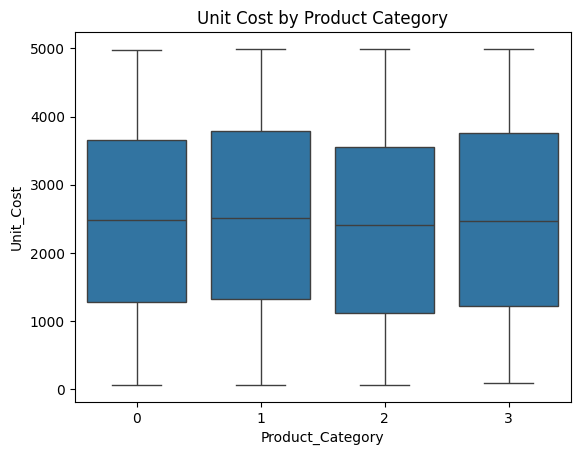

In [41]:
sns.boxplot(x='Product_Category', y='Unit_Cost', data=df)
plt.title('Unit Cost by Product Category')
plt.show()

# What is the distribution of Unit_Cost per product category?
# Boxplots show spread, median, and outliers—helpful to compare distributions across categories.

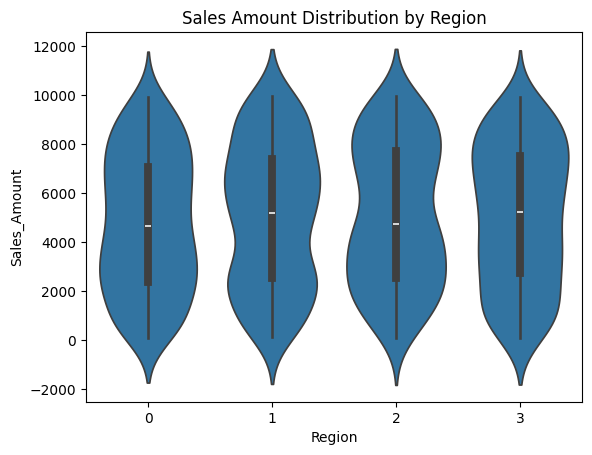

In [43]:
sns.violinplot(x='Region', y='Sales_Amount', data=df)
plt.title('Sales Amount Distribution by Region')
plt.show()

# Do different Regions have different sales amount distributions?
# Violin plots combine KDE with boxplot and show how data is distributed per region.

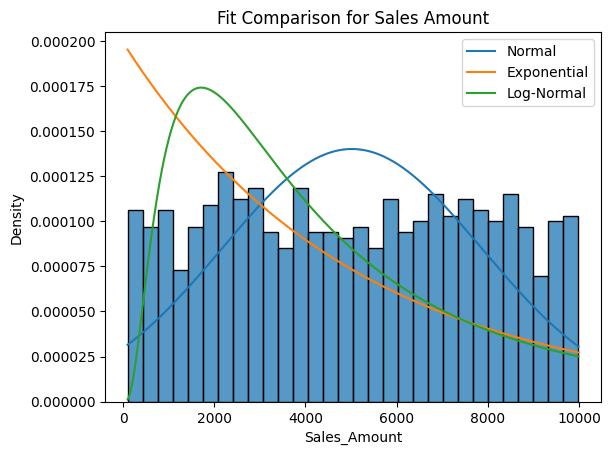

In [44]:
from scipy.stats import norm, expon, lognorm

data = df['Sales_Amount']
x = np.linspace(data.min(), data.max(), 1000)

sns.histplot(data, kde=False, stat='density', bins=30)

plt.plot(x, norm.pdf(x, data.mean(), data.std()), label='Normal')
plt.plot(x, expon.pdf(x, scale=data.mean()), label='Exponential')
shape, loc, scale = lognorm.fit(data, floc=0)
plt.plot(x, lognorm.pdf(x, shape, loc, scale), label='Log-Normal')

plt.legend()
plt.title('Fit Comparison for Sales Amount')
plt.show()

# Which distribution best fits Sales_Amount – Normal, Exponential, or Log-normal?
# Visually compare how closely different theoretical distributions match the actual data.

In [45]:
mean = df['Sales_Amount'].mean()
std = df['Sales_Amount'].std()

within_1sd = df[
    (df['Sales_Amount'] >= mean - std) &
    (df['Sales_Amount'] <= mean + std)
]

print(f"{len(within_1sd) / len(df) * 100:.2f}% of data lies within 1 standard deviation")

# What percentage of Sales_Amount falls within 1 standard deviation of the mean?
# If the data is normally distributed, ~68% should lie within ±1σ. Deviations hint at non-normality.

58.60% of data lies within 1 standard deviation


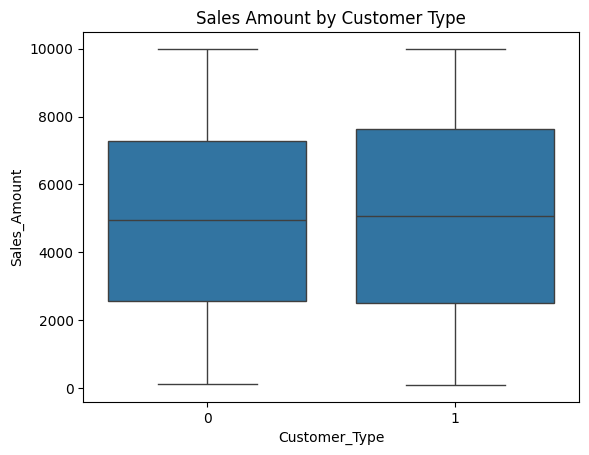

In [47]:
sns.boxplot(x='Customer_Type', y='Sales_Amount', data=df)
plt.title('Sales Amount by Customer Type')
plt.show()

# Is there a difference in Sales_Amount distribution between New vs Returning customers?
# Compare spread and central tendency. Large differences may indicate differing purchase behaviors.

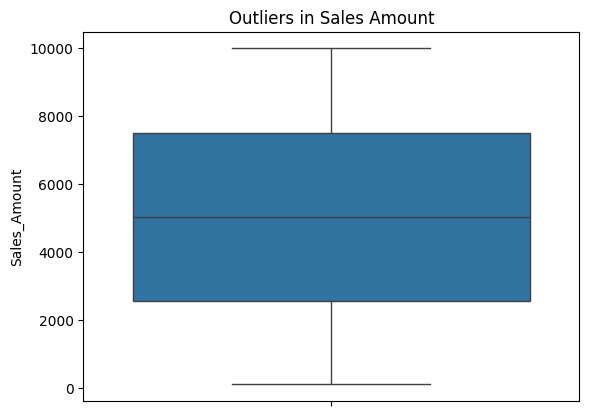

In [48]:
sns.boxplot(y=df['Sales_Amount'])
plt.title('Outliers in Sales Amount')
plt.show()
# Are there outliers in Sales_Amount?
# Boxplot whiskers highlight potential outliers. You can decide whether to cap, transform, or exclude them.